# Lecture Week 7: Data Analysis

In [2]:
import pandas as pd
import seaborn as sns

## How to melt columns to create long data

In [4]:
cars = pd.read_pickle('cars.pkl')
print(cars.shape)
# print(cars.enginesize.count()) # same as rows so no missing values
# print(cars.enginesize.value_counts())
# print(len(cars.enginesize.unique()))

# print(cars.curbweight.count()) # same as rows so no missing values
# print(len(cars.curbweight.unique()))
	
cars.head(3)

(205, 5)


,aspiration,carbody,enginesize,curbweight,price
0,std,convertible,130,2548,13495.0
1,std,convertible,130,2548,16500.0
2,std,hatchback,152,2823,16500.0


### Example: 
Melt the `'cars'` DataFrame using pandas `melt()` function

Keep the `'price'` column as the **identifier variable** (id_vars)

Select the `'enginesize'` and `'curbweight'` columns as the **value variables** (value_vars)

Rename the melted columns as `'feature'` and `'featureValue'` using `var_name` and `value_name` parameters.

In [6]:
cars_melted = pd.melt(cars, 
                      id_vars='price', # col to be kep as id
                      value_vars=['enginesize','curbweight'], # Variable and values: columns to be melt into rows
                      var_name='feature', # name of new column formed 
                      value_name='featureValue' # values of new column
                     )

print(cars.shape)
print(cars_melted.shape) # number of rows has been doubled. 
# Columns in neither argument are excluded
display(cars_melted.head(3))

# have  look at the middle part of df
middle = len(cars_melted) // 2
cars_melted.iloc[middle - 5:middle + 5]

(205, 5)
(410, 3)


,price,feature,featureValue
0,13495.0,enginesize,130
1,16500.0,enginesize,130
2,16500.0,enginesize,152


,price,feature,featureValue
200,16845.0,enginesize,141
201,19045.0,enginesize,141
202,21485.0,enginesize,173
203,22470.0,enginesize,145
204,22625.0,enginesize,141
205,13495.0,curbweight,2548
206,16500.0,curbweight,2548
207,16500.0,curbweight,2823
208,13950.0,curbweight,2337
209,17450.0,curbweight,2824


In [7]:
cars_melted = pd.melt(cars, id_vars='price', value_vars=['enginesize','curbweight'],
                      var_name='feature', value_name='featureValue')

# .isin() checks whether each value appears in a given list, set, Series or other collection. 
# It returns True or False.
cars_melted[cars_melted['price'].isin([13495.0,16500.0])] # df[df[...]] -> filtering is happening

,price,feature,featureValue
0,13495.0,enginesize,130
1,16500.0,enginesize,130
2,16500.0,enginesize,152
205,13495.0,curbweight,2548
206,16500.0,curbweight,2548
207,16500.0,curbweight,2823


## How to plot melted columns

Create a scatter plot using Seaborn's `relplot()` function.

 Use the `'cars_melted'` DataFrame as the data source.
 
Set `'featureValue'` as the x-axis variable and `'price'` as the y-axis variable.

Use `'feature'` as the hue variable to differentiate points by color.

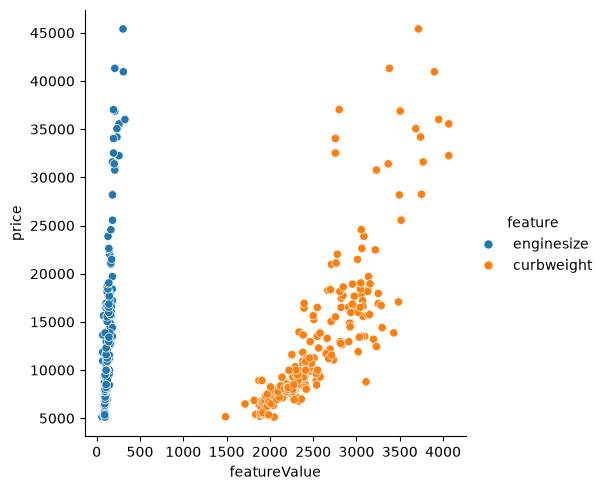

In [10]:
sns.relplot(data=cars_melted, x='featureValue', y='price', 
            hue='feature', # category
            # kind='line'
           )

Example:

Create a scatter plot using Seaborn's `relplot()` function.
 
 Use the `'cars_melted'` DataFrame as the data source.
 
 Set `'featureValue'` as the x-axis variable and `'price'` as the y-axis variable.
 
Use `'feature'` as the column variable to create subplots for each unique value of `'feature'`
 Set `facet_kws` to `{'sharex':False}` to disable sharing of the x-axis across subplots. With the **default shared x-axis**, all subplots use the same x-axis limits, which can make some plots look **compressed**.

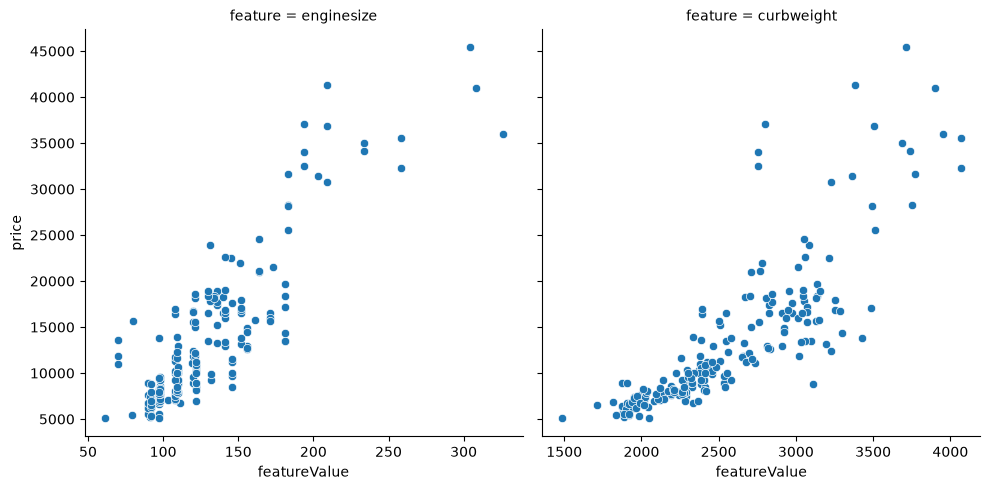

In [12]:
sns.relplot(data=cars_melted, x='featureValue', y='price', 
            col='feature', # Creates subplots across columns
            # row='feature', #Creates subplots across rows
            facet_kws={'sharex':False} # spreads more meaningfully according to data points distributions
                                    # different intervals on x-axis
           )
# tells Seaborn that each subplot should have its own independent x-axis scale.

## How to group and apply a single aggregate method

In [14]:
fires = pd.read_pickle('fires_prepared.pkl')
display(fires.head(5))

fires = fires.reset_index(drop=True) # False-> keeps idx as a col
display(fires.head(5))

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
16,Power,2004,CA,2004-10-06,2004-10-21,16823.0,10,15.0
17,Freds,2004,CA,2004-10-13,2004-10-17,7700.0,10,4.0
25,Bachelor,2004,NM,2004-07-20,2004-07-20,10.0,7,0.0
37,Howard Gap,2005,NC,2005-01-27,2005-01-28,50.3,1,1.0
39,Austin Creek,2005,NC,2005-02-12,2005-02-13,125.0,2,1.0


,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
0,Power,2004,CA,2004-10-06,2004-10-21,16823.0,10,15.0
1,Freds,2004,CA,2004-10-13,2004-10-17,7700.0,10,4.0
2,Bachelor,2004,NM,2004-07-20,2004-07-20,10.0,7,0.0
3,Howard Gap,2005,NC,2005-01-27,2005-01-28,50.3,1,1.0
4,Austin Creek,2005,NC,2005-02-12,2005-02-13,125.0,2,1.0


Group the `'fires'` DataFrame by the `'state'` column and calculate the mean of each group:

In [16]:
fires.groupby('state'
              # , sort=False
             ).mean(numeric_only=True).head(3) # Alphabetical order
# automatically applies only on numerical columns
# behaviour can differ between Pandas versions.

,fire_year,acres_burned,fire_month,days_burning
state,,,,
AK,2004.742504,11367.199362,6.264198,32.081535
AL,2003.885422,42.348169,5.022529,0.272676
AR,2005.850793,50.281673,5.581081,0.400992


### How groupby() Orders Groups

By default, Pandas groupby() sorts group keys in **ascending** order because:
Default is:
```python
df.groupby('column', sort=True)
```
* Text values: alphabetical order
* Numerical values: smallest to largest
* Datetime values: earliest to latest

Example:

Group the `'fires'` DataFrame by multiple columns - `'state'`, `'fire_year'`, and `'fire_month'`.

 Calculate the **maximum value of each group**.
 
 Display the first 3 rows of the resulting DataFrame using `head()` function.

In [19]:
fires.groupby(['state', 'fire_year', 'fire_month']).max(numeric_only=True).head(3)

# OR

fires.groupby(['state', 'fire_year', 'fire_month'])[['acres_burned', 'days_burning']].max().head(3)

acres_burned  days_burning
state fire_year fire_month                            
AK    1992      5                 1410.0          50.0
                6                48087.0          82.0
                7                35090.0          77.0

## How to work with a DataFrameGroupBy object

In [21]:
fires.head(3)

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
0,Power,2004,CA,2004-10-06,2004-10-21,16823.0,10,15.0
1,Freds,2004,CA,2004-10-13,2004-10-17,7700.0,10,4.0
2,Bachelor,2004,NM,2004-07-20,2004-07-20,10.0,7,0.0


In [22]:
# Group the 'fires' DataFrame by the 'fire_year' column using the groupby() function
yearly_group = fires.groupby('fire_year')
# Calculate the saum of each group using thea sum() function
yearly_sums = yearly_group.sum(numeric_only=True) # if not specified can raise error or meaningless results
yearly_sums.head(3)

,acres_burned,fire_month,days_burning
fire_year,,,
1992,2123889.91,45643,6230.0
1993,2118394.10,52880,7283.0
1994,4033880.06,57669,20158.0


In [23]:
# Group the 'fires' DataFrame by the 'fire_year' column using the groupby() function
# Set the 'as_index' parameter to False to keep the grouping column as 
# a regular column in the resulting DataFrame
yearly_group = fires.groupby('fire_year', as_index=False) # fire_year remains a normal column.
# Calculate the sum of each group using the sum() function
yearly_sums = yearly_group.sum(numeric_only=True)
# Display the first 3 rows of the resulting DataFrame using head() function
yearly_sums.head(3)

,fire_year,acres_burned,fire_month,days_burning
0,1992,2123889.91,45643,6230.0
1,1993,2118394.10,52880,7283.0
2,1994,4033880.06,57669,20158.0


## How to apply multiple aggregate methods

In [25]:
# Group the 'fires' DataFrame by multiple columns - 'state', 'fire_year', and 'fire_month'
monthly_group = fires.groupby(['state','fire_year','fire_month'], as_index=False)
# Calculate the sum, count, and mean of each group using the agg() function
monthly_group[['acres_burned', 'days_burning']].agg(['sum','count','mean']).head(3)

state fire_year fire_month acres_burned                    days_burning  \
                                      sum count         mean          sum   
0    AK      1992          5       4202.0    15   280.133333        135.0   
1    AK      1992          6      86401.0    26  3323.115385        417.0   
2    AK      1992          7      48516.7    26  1866.026923        500.0   

                    
  count       mean  
0    14   9.642857  
1    25  16.680000  
2    22  22.727273

In [26]:
# Group the 'fires' DataFrame by multiple columns - 
# 'state', 'fire_year', and 'fire_month'
monthly_group = fires.groupby(['state','fire_year','fire_month'])
# Calculate the sum, count, and mean of the 'days_burning' column 
# for each group using the agg() function
monthly_group.days_burning.agg(['sum','count','mean']).head(3)

sum  count       mean
state fire_year fire_month                         
AK    1992      5           135.0     14   9.642857
                6           417.0     25  16.680000
                7           500.0     22  22.727273

In [27]:
# Group the 'fires' DataFrame by multiple columns - 'state', 'fire_year', and 'fire_month'
monthly_group = fires.groupby(['state','fire_year','fire_month'])
# Calculate various aggregations for different columns 
# using the agg() function and a dictionary
df = monthly_group.agg({'acres_burned':['sum','max','min'],
                        'days_burning':['sum','mean'],
                        'fire_name':'count'})
df.head(3)

acres_burned                days_burning  \
                                    sum      max   min          sum   
state fire_year fire_month                                            
AK    1992      5                4202.0   1410.0  10.0        135.0   
                6               86401.0  48087.0  10.0        417.0   
                7               48516.7  35090.0  10.0        500.0   

                                      fire_name  
                                 mean     count  
state fire_year fire_month                       
AK    1992      5            9.642857        14  
                6           16.680000        23  
                7           22.727273        26

## How to use the pivot() method

In [29]:
display(fires.head(2))
# Define a list of states to filter for
states = ['AK','CA','ID','TX']
# Group the 'fires' DataFrame by 'state' and 'fire_year' columns, 
# and calculate the sum for each group
# Reset the index and store the result in the 'top_states' DataFrame
top_states = fires.groupby(['state','fire_year'], as_index=False).sum(numeric_only=True)

# Filter the 'top_states' DataFrame to only include rows 
# where the 'state' is in the defined list of states
top_states = top_states.query('state in @states') 
# top_states = top_states[top_states['state'].isin(states)]
top_states.head(10)

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
0,Power,2004,CA,2004-10-06,2004-10-21,16823.0,10,15.0
1,Freds,2004,CA,2004-10-13,2004-10-17,7700.0,10,4.0


,state,fire_year,acres_burned,fire_month,days_burning
0,AK,1992,1.424447e+05,454,1145.0
1,AK,1993,6.866305e+05,961,3373.0
2,AK,1994,2.616047e+05,810,2517.0
3,AK,1995,4.376260e+04,278,880.0
4,AK,1996,5.984072e+05,650,2112.0
5,AK,1997,2.025818e+06,1092,2295.0
6,AK,1998,1.206034e+05,249,435.0
7,AK,1999,1.005597e+06,743,2312.0
8,AK,2000,7.561614e+05,368,1745.0
9,AK,2001,2.197077e+05,204,1659.0


### Example: 
Pivot the 'top_states' DataFrame with 'fire_year' as index, `state'` as columns, 
and `'acres_burned'` as values. Store the result in a new DataFrame.

`pivot()` spreads the unique values from one column across new column headers.
| Parameter | Purpose                                              |
| --------- | ---------------------------------------------------- |
| `index`   | Column whose values become the new row labels        |
| `columns` | Column whose unique values become new column headers |
| `values`  | Column containing the values placed inside the table |

In [31]:
display(top_states.head(2))
top_states_pivot = top_states.pivot(index='fire_year', 
                                    columns='state', 
                                    values='acres_burned'
                                   )
display(top_states_pivot.head(2))

,state,fire_year,acres_burned,fire_month,days_burning
0,AK,1992,142444.7,454,1145.0
1,AK,1993,686630.5,961,3373.0


state,AK,CA,ID,TX
fire_year,,,,
1992,142444.7,289254.9,683495.2,31500.3
1993,686630.5,315011.1,7658.5,114265.5


<Axes: xlabel='fire_year'>

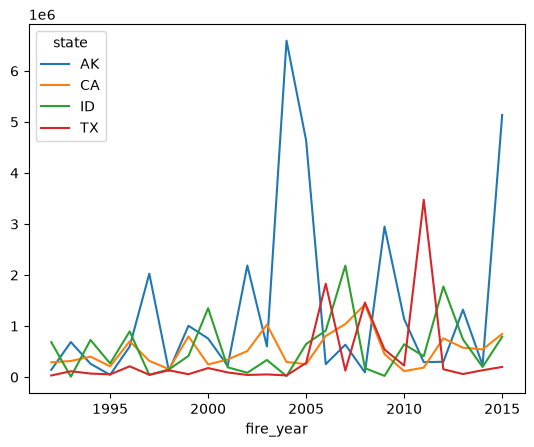

In [32]:
# Pivot the 'top_states' DataFrame with 'fire_year' as index, 'state' as columns, 
# and 'acres_burned' as values
# Store the result in a new DataFrame
top_states_pivot = top_states.pivot(index='fire_year', columns='state', values='acres_burned')
# Plot the pivoted DataFrame using plot() function
# The resulting plot will show the trend of acres burned over time for each state
top_states_pivot.plot()# index->x horizontal axis, values->t vertical axis

Important condition

Each combination of index and columns must identify exactly one row.


## How to use the pivot_table() method
Both reshape data from long format to wide format, but the key difference is how they handle duplicate combinations.

| Feature                | `df.pivot()`      | `df.pivot_table()`                  |
| ---------------------- | ----------------- | ----------------------------------- |
| Purpose                | Reshape data      | Reshape and summarise data          |
| Duplicate combinations | Produces an error | Combines them using an aggregation  |
| Aggregation            | Not supported     | Supported using `aggfunc`           |
| Default aggregation    | None              | Mean                                |
| Missing combinations   | Produces `NaN`    | Produces `NaN` or uses `fill_value` |


In [34]:
# Create a list of states to filter, including only 'AK', 'CA', 'ID', and 'TX'
states = ['AK','CA','ID','TX']
# Filter the 'fires' DataFrame to include only rows where 'state' is in the list of states
fires_top_4 = fires.query('state in @states')
# Pivot the filtered DataFrame with 'fire_year' as index, 'state' as columns, and 'acres_burned' as values
# Use 'mean' as the aggregation function for the values
fires_top_4 = fires_top_4.pivot_table(index='fire_year', columns='state', 
                                      values='acres_burned', aggfunc='mean')
fires_top_4.head(2)

state,AK,CA,ID,TX
fire_year,,,,
1992,1978.398611,338.705972,2309.105405,79.950000
1993,4608.258389,416.681349,159.552083,215.189266


<Axes: xlabel='fire_year'>

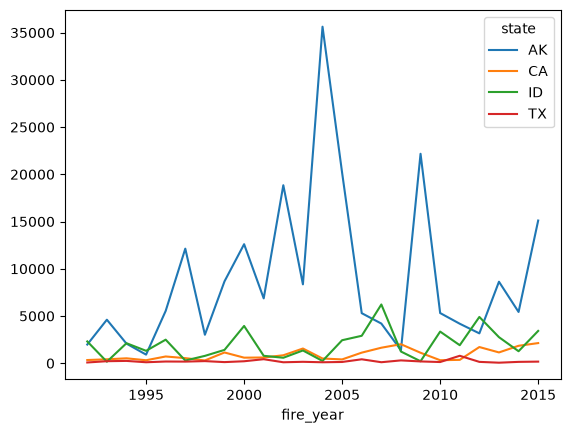

In [35]:
# The resulting plot will show the trend of acres burned over time for 
# each of the top 4 states (AK, CA, ID, TX)
fires_top_4.plot()

## Binning Data with `pd.cut()`

Binning means converting **continuous** numerical values into **categories** or **ranges**.

For example, instead of keeping every exact fire size:

`12, 48, 275, 900, 2500`

we can group them into:

`Small, Medium, Large`
#### How to create bins of equal size

In [37]:
fires_filtered = fires.query('fire_year == 2010 and days_burning > 0').dropna()
display(fires_filtered.head(3))
acres_burned_bins = pd.cut(fires_filtered.acres_burned, bins=4)
display(acres_burned_bins)

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
173229,Fourmile Trail,2010,AK,2010-04-28,2010-05-05,16.8,4,7.0
173230,Granite Tors,2010,AK,2010-05-27,2010-08-11,7880.0,5,76.0
173231,Goldbug Creek,2010,AK,2010-06-23,2010-06-28,2777.0,6,5.0


173229    (-296.103, 76535.75]
173230    (-296.103, 76535.75]
173231    (-296.103, 76535.75]
173232    (-296.103, 76535.75]
173233    (-296.103, 76535.75]
                  ...         
273969    (-296.103, 76535.75]
274046    (-296.103, 76535.75]
274049    (-296.103, 76535.75]
274081    (-296.103, 76535.75]
274116    (-296.103, 76535.75]
Name: acres_burned, Length: 1858, dtype: category
Categories (4, interval[float64, right]): [(-296.103, 76535.75] < (76535.75, 153061.5] < (153061.5, 229587.25] < (229587.25, 306113.0]]

In [38]:
# Use the `cut()` function from the pandas library to bin the 'acres_burned' column 
# of the `fires_filtered` data frame into custom bins
# The bins are specified as a list of interval edges
acres_burned_bins = pd.cut(fires_filtered.acres_burned,
                           bins=[0,100000,200000,300000,400000] # boundary = bins +1
                          )
acres_burned_bins.head()

173229    (0, 100000]
173230    (0, 100000]
173231    (0, 100000]
173232    (0, 100000]
173233    (0, 100000]
Name: acres_burned, dtype: category
Categories (4, interval[int64, right]): [(0, 100000] < (100000, 200000] < (200000, 300000] < (300000, 400000]]

In [39]:
# Use the `cut()` function from the pandas library to bin the 'acres_burned' column 
# of the `fires_filtered` data frame into custom bins
# The bins are specified as a list of interval edges, and the bin labels are specified as another list
acres_burned_bins = pd.cut(fires_filtered.acres_burned, bins=[0,100000,200000,300000,400000], 
                           labels=['small','medium','large','very large'])
display(acres_burned_bins)

173229    small
173230    small
173231    small
173232    small
173233    small
          ...  
273969    small
274046    small
274049    small
274081    small
274116    small
Name: acres_burned, Length: 1858, dtype: category
Categories (4, str): ['small' < 'medium' < 'large' < 'very large']

In [40]:
# Use the `cut()` function from the pandas library to bin the 'acres_burned' column 
# of the `fires_filtered` data frame into custom bins
# The bins are specified as a list of interval edges, and the bin labels are specified as another list
# The resulting `Categorical` object is then passed to the 
# `value_counts()` method to count the number of values in each bin

In [41]:
acres_burned_bins = pd.cut(fires_filtered.acres_burned, 
                           bins=[0,100000,200000,300000,400000], 
                           labels=['small','medium','large','very large']).value_counts()
display(acres_burned_bins)

acres_burned
small         1855
medium           2
very large       1
large            0
Name: count, dtype: int64

## How to create bins with equally distributed data points

**Automatically** create **equal-width** bins

However, these automatically calculated boundaries may not have meaningful **real-world interpretations**. 

**Manually selected boundaries** are often more understandable.

`pd.cut()` versus `pd.qcut()`

In [43]:
acres_burned_bins = pd.qcut(fires_filtered.acres_burned, 
                            q=4, 
                            labels=['small','medium','large','very large']
                           )
acres_burned_counts = acres_burned_bins.value_counts()
display(acres_burned_bins,acres_burned_counts)

173229         small
173230    very large
173231    very large
173232         large
173233        medium
             ...    
273969         small
274046        medium
274049        medium
274081         small
274116        medium
Name: acres_burned, Length: 1858, dtype: category
Categories (4, str): ['small' < 'medium' < 'large' < 'very large']

acres_burned
small         466
medium        465
very large    464
large         463
Name: count, dtype: int64

In [44]:
# Use pd.qcut to categorize fires_filtered.days_burning into 4 equal quantiles with labels
# 'short', 'medium', and 'long', and then count the occurrences of each category.
# The 'duplicates' parameter is set to 'drop' to drop any duplicate values from the result.
# pd.qcut(fires_filtered.days_burning, q=4, labels=['short', 'medium', 'long'], duplicates='drop').value_counts()

## How to plot the binned data

In [46]:
# Display the first few rows of the fires_filtered DataFrame using the .head() method
fires_filtered.head(3)

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
173229,Fourmile Trail,2010,AK,2010-04-28,2010-05-05,16.8,4,7.0
173230,Granite Tors,2010,AK,2010-05-27,2010-08-11,7880.0,5,76.0
173231,Goldbug Creek,2010,AK,2010-06-23,2010-06-28,2777.0,6,5.0


In [47]:
# Use sns.catplot to create a count plot from the fires_filtered DataFrame,
# with the x-axis representing 'fire_month' and the hue representing 'fire_size'
fires_filtered['fire_size']= pd.qcut(fires_filtered.acres_burned, 
                            q=4, 
                            labels=['small','medium','large','very large']
                           )

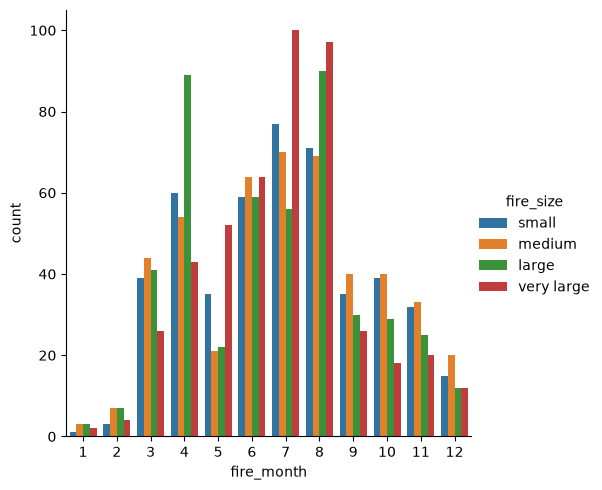

In [48]:
sns.catplot(data=fires_filtered, kind='count', x='fire_month', hue='fire_size')

## How to get the top n rows

In [50]:
# Retrieve the top 6 rows from the 'cars' DataFrame based on 
# the largest values in the 'enginesize' column
cars.nlargest(n=6, columns='enginesize')

,aspiration,carbody,enginesize,curbweight,price
49,std,sedan,326,3950,36000.0
73,std,sedan,308,3900,40960.0
74,std,hardtop,304,3715,45400.0
47,std,sedan,258,4066,32250.0
48,std,sedan,258,4066,35550.0
71,std,sedan,234,3740,34184.0


In [51]:
# Retrieve the top 6 rows from the 'cars' DataFrame based on 
# the largest values in the 'enginesize' and 'price' columns
cars.nlargest(n=6, columns=['enginesize', 'price'])

,aspiration,carbody,enginesize,curbweight,price
49,std,sedan,326,3950,36000.0
73,std,sedan,308,3900,40960.0
74,std,hardtop,304,3715,45400.0
48,std,sedan,258,4066,35550.0
47,std,sedan,258,4066,32250.0
72,std,convertible,234,3685,35056.0


## How to calculate percent change

In [53]:
# Extract the 'state', 'fire_year', and 'acres_burned' columns from the 'fires' DataFrame
# and group them by 'state' and 'fire_year' using the .groupby() method
# Then, calculate the sum of 'acres_burned' for each group using the .sum() method
df = fires[['state', 'fire_year', 'acres_burned']].groupby(['state', 'fire_year']).sum() # already selected numeric columns.
display(df)

acres_burned
state fire_year              
AK    1992          142444.70
      1993          686630.50
      1994          261604.70
      1995           43762.60
      1996          598407.20
...                       ...
WY    2011          134336.25
      2012          481206.46
      2013           53884.90
      2014            7179.43
      2015           36233.50

[1148 rows x 1 columns]

In [54]:
# Calculate the percentage change of each element in the 'df' DataFrame
display(df.pct_change())

acres_burned
state fire_year              
AK    1992                NaN
      1993           3.820330
      1994          -0.619002
      1995          -0.832715
      1996          12.673941
...                       ...
WY    2011           0.552941
      2012           2.582104
      2013          -0.888021
      2014          -0.866764
      2015           4.046849

[1148 rows x 1 columns]

## How to rank rows

In [56]:
# Group the 'fires' DataFrame by 'state' and calculate the sum of 
# 'acres_burned', and 'days_burning'Then, extract the columns 
# 'acres_burned',  and 'days_burning' using double square brackets
# Finally, assign the resulting DataFrame to the variable 'df' and display 
# the first 3 rows using the .head() method
display(fires.head(3))

# df1= fires.groupby('state').sum(numeric_only=True)
# display(df1.head(3))

df = fires.groupby('state')[['acres_burned', 'days_burning']].sum()
display(df.head(3))

df1 = fires.groupby('state').sum(numeric_only=True)[
['acres_burned','days_burning']
]
display(df1.head(3))

,fire_name,fire_year,state,discovery_date,contain_date,acres_burned,fire_month,days_burning
0,Power,2004,CA,2004-10-06,2004-10-21,16823.0,10,15.0
1,Freds,2004,CA,2004-10-13,2004-10-17,7700.0,10,4.0
2,Bachelor,2004,NM,2004-07-20,2004-07-20,10.0,7,0.0


,acres_burned,days_burning
state,,
AK,3.222601e+07,80268.0
AL,8.101628e+05,2886.0
AR,4.502221e+05,1132.0


,acres_burned,days_burning
state,,
AK,3.222601e+07,80268.0
AL,8.101628e+05,2886.0
AR,4.502221e+05,1132.0


In [57]:
# Add a new column to the 'df' DataFrame, named 'acres_rank', 
# which contains the rank of 'acres_burned'
# calculated in descending order using the .rank() method 
# with the 'ascending=False' parameter
df = fires.groupby('state')[['acres_burned', 'days_burning']].sum()
display(df.head(3))

df['acres_rank'] = df.acres_burned.rank(ascending=False)
df.head(3)

,acres_burned,days_burning
state,,
AK,3.222601e+07,80268.0
AL,8.101628e+05,2886.0
AR,4.502221e+05,1132.0


,acres_burned,days_burning,acres_rank
state,,,
AK,3.222601e+07,80268.0,1.0
AL,8.101628e+05,2886.0,23.0
AR,4.502221e+05,1132.0,27.0


In [58]:
# Add a new column to the 'df' DataFrame, named 'days_rank', 
# which contains the rank of 'days_burning'
# calculated using the 'max' method, where each group of equal values receives the maximum rank
# using the .rank() method with the 'method='max'' parameter
display(df.head(3))
df['days_rank'] = df.days_burning.rank(method='max')
# Sort the 'df' DataFrame by the 'days_burning' column 
# in ascending order using the .sort_values() method
df.sort_values('days_burning').head(4)

,acres_burned,days_burning,acres_rank
state,,,
AK,3.222601e+07,80268.0,1.0
AL,8.101628e+05,2886.0,23.0
AR,4.502221e+05,1132.0,27.0


,acres_burned,days_burning,acres_rank,days_rank
state,,,,
RI,147.45,0.0,51.0,1.0
CT,7358.20,6.0,46.0,3.0
VT,985.70,6.0,50.0,3.0
NH,1232.23,9.0,49.0,4.0
